# Chemical Exchange
## Ref: Plotting Figure 6, Essentail tools of linear algebra for calculating nuclear spin dynamics of chemically exchangeing systems, Jingyan Xi and Danila A Barskiy. (https://www.sciencedirect.com/science/article/pii/S2666441023000407)
### Author: Vineeth Thalakottoor, IE CNRS, LSDRM, CEA, Paris-Saclay (vineeth.thalakottoor@cea.fr)

In [1]:
# Define the source path
SourcePath = "/home/vineeth/Documents/PyOR/PyOR"

# Add source path
import sys
sys.path.append(SourcePath)

import time
%matplotlib inline

# Import PyOR package
from PyORv2 import *

*****        ***** *****
*   *        *   * *   *
*****  *   * *   * *****
*       * *  *   * * *  
*        *   ***** *  * 
        *               
       *                
Welcome to Python On Resonance (PyOR)

Author: Vineeth Thalakottoor, IE CNRS, LSDRM, CEA, Paris-Saclay

Email: vineeth.thalakottoor@cea.fr

"Everybody can simulate Magnetic Resonance"

Imported modules:

* QunS                   (QuantumSystem from PyOR_QuantumSystem)
* QuantumSystems         (QuantumSystems from PyOR_QuantumSystem - for multiple systems)
** Hamiltonian           (from PyOR_Hamiltonian)
** DensityMatrix         (from PyOR_DensityMatrix)
** HardPulse             (from PyOR_HardPulse)
** Basis                 (from PyOR_Basis)
** RelaxationProcess     (from PyOR_Relaxation)
** Evolutions            (from PyOR_Evolution)
** Plotting              (from PyOR_Plotting)
** Spro                  (from PyOR_SignalProcessing)
** constants             (from PyOR_PhysicalConstants)
** gamma                 (f

### Parameters 

In [2]:
# Magnetic Field
B0 = 18.8
offset_N = 0.0
offset_H = gamma("H1","MHz/T") * B0

# Chemical kinetics constant
K_A = 2.2e-10

#pH
pH = 4.6 # -0.8, 1.0, 2.1, 3.4, 4.6

# Dissociation rates
kd = 80000 # 10, 30, 250, 5000, 80000

W = 10**(-pH)/K_A

# J coupling
J_NH = -73.4
J_HH = -16.9

# Relaxation time
T1_N  = 5.0
T1_H1 = 1.0
T1_H2 = 1.0
T1_H3 = 1.0
T1_H4 = 1.0

# Acq Parameters
dt = 1.0/600.0

### Define Spin System

In [3]:
QS = QuantumSystems(
    {
        "A": {
            "N":  "N15",
            "H1": "H1",
            "H2": "H1",
            "H3": "H1",
        }
    },
    {
        "B": {
            "N":  "N15",
            "H1": "H1",
            "H2": "H1",
            "H3": "H1",
            "H4": "H1",
        }
    }
)


Spin Operators generated (Quantum Objects)
For particle N: Nx, Ny, Nz, Np, Nm
For particle H1: H1x, H1y, H1z, H1p, H1m
For particle H2: H2x, H2y, H2z, H2p, H2m
For particle H3: H3x, H3y, H3z, H3p, H3m

To see the matrix form use the attribute .matrix
Spin Operators generated (Quantum Objects)
For particle N: Nx, Ny, Nz, Np, Nm
For particle H1: H1x, H1y, H1z, H1p, H1m
For particle H2: H2x, H2y, H2z, H2p, H2m
For particle H3: H3x, H3y, H3z, H3p, H3m
For particle H4: H4x, H4y, H4z, H4p, H4m

To see the matrix form use the attribute .matrix


In [4]:
QS.Configure(
    B0=B0,
    PropagationSpace="Liouville",
    MasterEquation="Lindblad",
    Rprocess="Lindblad T1",
    AcqDT = dt,
    AcqAQ = 7.0,
    PropagationMethod = "Unitary Propagator System",
    
    PlotFigureSize = (10,5),
    PlotFontSize = 20,

    A={
        "OFFSET": {
            "N": offset_N,
            "H1": offset_H,
            "H2": offset_H,
            "H3": offset_H,
        },

        "Jcouplings": [
            ["N",  "H1", J_NH],
            ["N",  "H2", J_NH],
            ["N",  "H3", J_NH],
            ["H1", "H2", J_HH],
            ["H1", "H3", J_HH],
            ["H2", "H3", J_HH],
        ],

        "Lindblad_T1": {
            "N":  5.0,
            "H1": 1.0,
            "H2": 1.0,
            "H3": 1.0,
        },
    },

    B={
        "OFFSET": {
            "N": offset_N,
            "H1": offset_H,
            "H2": offset_H,
            "H3": offset_H,
            "H4": offset_H,
        },

        "Jcouplings": [
            ["N",  "H1", J_NH],
            ["N",  "H2", J_NH],
            ["N",  "H3", J_NH],
            ["N",  "H4", J_NH],
            ["H1", "H2", J_HH],
            ["H1", "H3", J_HH],
            ["H1", "H4", J_HH],
            ["H2", "H3", J_HH],
            ["H2", "H4", J_HH],
            ["H3", "H4", J_HH],
        ],

        "Lindblad_T1": {
            "N":  5.0,
            "H1": 1.0,
            "H2": 1.0,
            "H3": 1.0,
            "H4": 1.0,
        },
    },
)

Spin Operators generated (Quantum Objects)
For particle N: Nx, Ny, Nz, Np, Nm
For particle H1: H1x, H1y, H1z, H1p, H1m
For particle H2: H2x, H2y, H2z, H2p, H2m
For particle H3: H3x, H3y, H3z, H3p, H3m

To see the matrix form use the attribute .matrix

Setting derived parameters from dictionaries
-------------------------------------------
OmegaRF   <- OMEGA_RF  : [509972191.52, -5029416006.400001, -5029416006.400001, -5029416006.400001] from {'N': 509972191.52, 'H1': -5029416006.400001, 'H2': -5029416006.400001, 'H3': -5029416006.400001}
Offset    <- OFFSET    : [0.0, 800.4564182840595, 800.4564182840595, 800.4564182840595] from {'N': 0.0, 'H1': 800.4564182840595, 'H2': 800.4564182840595, 'H3': 800.4564182840595}
Ispintemp <- I_spintemp: [300, 300, 300, 300] from {'N': 300, 'H1': 300, 'H2': 300, 'H3': 300}
Fspintemp <- F_spintemp: [300, 300, 300, 300] from {'N': 300, 'H1': 300, 'H2': 300, 'H3': 300}
RDxi      <- RD_xi     : [0, 0, 0, 0] from {'N': 0, 'H1': 0, 'H2': 0, 'H3': 0}
RDphase 

### Hamiltonian

In [5]:
# Zeeman for systemv A
Hz_A = -QS.A.OFFSET["N"] * QS.A.Nz - QS.A.OFFSET["H1"] * (QS.A.H1z + QS.A.H2z + QS.A.H3z)
#Hz_A.matrix

In [6]:
# Zeeman for systemv B
Hz_B = -QS.B.OFFSET["N"] * QS.B.Nz - QS.B.OFFSET["H1"] * (QS.B.H1z + QS.B.H2z + QS.B.H3z  + QS.B.H4z)
#Hz_B.matrix

In [7]:
# J coupling for system A

HJ0_NH3 = J_HH * (
      QS.A.H1x * QS.A.H2x
    + QS.A.H1y * QS.A.H2y
    + QS.A.H1z * QS.A.H2z

    + QS.A.H1x * QS.A.H3x
    + QS.A.H1y * QS.A.H3y
    + QS.A.H1z * QS.A.H3z

    + QS.A.H2x * QS.A.H3x
    + QS.A.H2y * QS.A.H3y
    + QS.A.H2z * QS.A.H3z
)

HJ1_NH3 = J_NH * (
      QS.A.Nz * QS.A.H1z
    + QS.A.Nz * QS.A.H2z
    + QS.A.Nz * QS.A.H3z
)

Hj_A = HJ0_NH3 + HJ1_NH3
#Hj_A.matrix

In [8]:
# J coupling for system B

HJ0_NH4 = J_HH * (
      QS.B.H1x * QS.B.H2x
    + QS.B.H1y * QS.B.H2y
    + QS.B.H1z * QS.B.H2z

    + QS.B.H1x * QS.B.H3x
    + QS.B.H1y * QS.B.H3y
    + QS.B.H1z * QS.B.H3z

    + QS.B.H1x * QS.B.H4x
    + QS.B.H1y * QS.B.H4y
    + QS.B.H1z * QS.B.H4z

    + QS.B.H2x * QS.B.H3x
    + QS.B.H2y * QS.B.H3y
    + QS.B.H2z * QS.B.H3z

    + QS.B.H2x * QS.B.H4x
    + QS.B.H2y * QS.B.H4y
    + QS.B.H2z * QS.B.H4z

    + QS.B.H3x * QS.B.H4x
    + QS.B.H3y * QS.B.H4y
    + QS.B.H3z * QS.B.H4z
)


HJ1_NH4 = J_NH * (
      QS.B.Nz * QS.B.H1z
    + QS.B.Nz * QS.B.H2z
    + QS.B.Nz * QS.B.H3z
    + QS.B.Nz * QS.B.H4z
)


Hj_B = HJ0_NH4 + HJ1_NH4

#Hj_B.matrix

In [9]:
# Total Hamiltonian

Htotal_A = 2.0 * QS.A.pi * (Hz_A + Hj_A) 
Htotal_B = 2.0 * QS.A.pi * (Hj_B) 

Htotal_A_L = QS.A.QuantumLibrary.CommutationSuperoperator(Htotal_A)
Htotal_B_L = QS.B.QuantumLibrary.CommutationSuperoperator(Htotal_B)

### Relaxation

In [10]:
# Relaxation System A

R_A = QS.A.RelaxationProcess.Relaxation()

# Relaxation System B
R_B = QS.B.RelaxationProcess.Relaxation()

### Liouvillian

In [11]:
L_A = -1j * Htotal_A_L + R_A
L_B = -1j * Htotal_B_L + R_B

### Partial Trace Superoperator

In [12]:
# Partial-trace superoperators: NH4 -> NH3

Tr1 = QS.B.Evolutions.PartialTrace_Superoperator(
    keep=[0, 2, 3, 4],
    QuantumObject=True
)

Tr2 = QS.B.Evolutions.PartialTrace_Superoperator(
    keep=[0, 1, 3, 4],
    QuantumObject=True
)

Tr3 = QS.B.Evolutions.PartialTrace_Superoperator(
    keep=[0, 1, 2, 4],
    QuantumObject=True
)

Tr4 = QS.B.Evolutions.PartialTrace_Superoperator(
    keep=[0, 1, 2, 3],
    QuantumObject=True
)

Tr = (Tr1 + Tr2 + Tr3 + Tr4) / 4.0

### Kronecker Superoperator

In [13]:
rho_H = QS.A.Eye(2) / 2.0

Kron1 = QS.A.Evolutions.Kronecker_Superoperator(
    rho_H,
    insert_at=1
)

Kron2 = QS.A.Evolutions.Kronecker_Superoperator(
    rho_H,
    insert_at=2
)

Kron3 = QS.A.Evolutions.Kronecker_Superoperator(
    rho_H,
    insert_at=3
)

Kron4 = QS.A.Evolutions.Kronecker_Superoperator(
    rho_H,
    insert_at=4
)

Kron = (Kron1 + Kron2 + Kron3 + Kron4) / 4.0

### Inital density matrix and observables

In [14]:
# Initial density operators
rho_A = gamma("N15", "MHz/T")*QS.A.Nx + gamma("H1", "MHz/T")*(QS.A.H1z + QS.A.H2z + QS.A.H3z)
rho_B = gamma("N15", "MHz/T")*QS.B.Nx + gamma("H1", "MHz/T")*(QS.B.H1z + QS.B.H2z + QS.B.H3z + QS.B.H4z)

rho_A_L = 1.0/W * QS.A.QuantumLibrary.DMToVec(rho_A)
rho_B_L = QS.B.QuantumLibrary.DMToVec(rho_B)

In [15]:
rho_in = QS.A.Block([[rho_A_L],[rho_B_L]])

In [16]:
# Observable
det_A = QS.A.Np
det_B = QS.B.Np

det_A_L = QS.A.QuantumLibrary.DMToVec(det_A)
det_B_L = QS.B.QuantumLibrary.DMToVec(det_B)

In [17]:
det = QS.A.Block([[det_A_L],[det_B_L]])

### Evolution

In [18]:
L = QS.A.Block([[L_A - kd * W * QS.A.Eye(4**4), kd * Tr],[kd * W * Kron, L_B - kd * QS.A.Eye(4**5)]])

In [19]:
start_time = time.time()
t, rho_t = QS.A.Evolutions.Evolution(rho_in,rho_in,L )
end_time = time.time()
timetaken = end_time - start_time
print("Total time = %s seconds " % (timetaken))

Total time = 2.843644380569458 seconds 


In [20]:
t, signal = QS.A.Evolutions.Expectation(rho_t,det)

/home/vineeth/venv/pyorv2/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/vineeth/venv/pyorv2/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(<Figure size 1000x500 with 1 Axes>,
 <matplotlib.widgets.SpanSelector at 0x7fb6781974d0>)

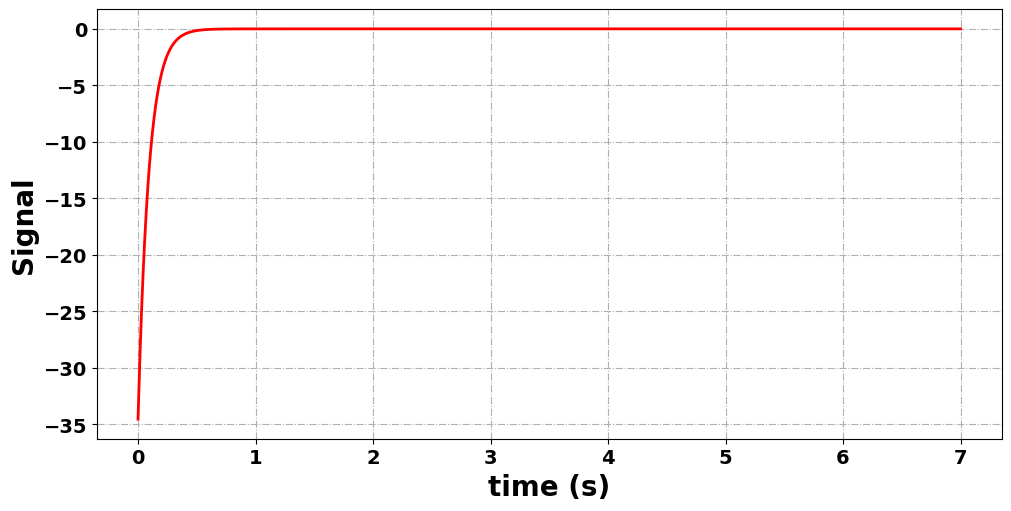

In [21]:
QS.A.Plotting.Plotting_SpanSelector(t,signal,"time (s)","Signal","red")

### Spectrum

In [22]:
freq, spectrum = QS.A.Spro.FourierTransform(signal,QS.A.AcqFS,5)

(<Figure size 1000x500 with 1 Axes>,
 <matplotlib.widgets.SpanSelector at 0x7fb575054c50>)

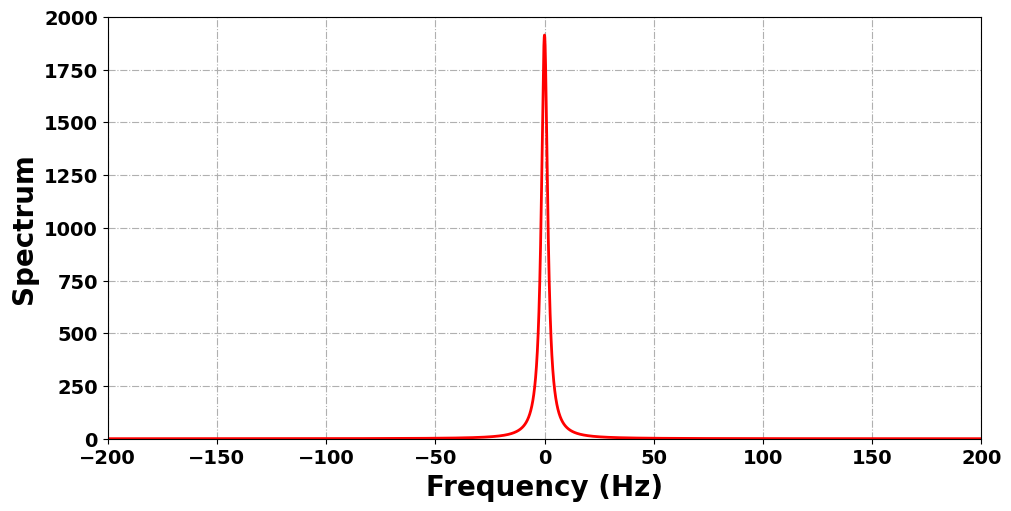

In [23]:
QS.A.Plotting.PlotXlimt= (-200,200)
QS.A.Plotting.PlotYlimt= (0,2000)
QS.A.Plotting.Plotting_SpanSelector(freq,-spectrum,"Frequency (Hz)","Spectrum","red")